In [1]:
import geopandas as gpd
import sys
sys.path.append('..')
import osmnx as ox
from shapely import Polygon, MultiPolygon


# Graph

In [2]:
geocode=81993
polygon = ox.geocode_to_gdf(f'R{geocode}', by_osmid=True)
local_crs = 32637

In [3]:
from transport_frames.graph import Graph

g = Graph(polygon,local_crs)

/Users/polina/Desktop/tf2/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-02-17 11:08:41.692 | INFO     | iduedu.modules.drive_walk_builder:get_drive_graph_by_poly:91 - Downloading drive graph from OSM, it may take a while for large territory ...


# Frame

In [4]:
regions = gpd.read_file('/Users/polina/Desktop/github/transport_frames/data/lo_gdfs/regions_of_russia.geojson')
regions = regions[regions['ISO3166-2']!='RU-CHU']
regions = regions[regions['geometry'].apply(lambda x: isinstance(x, (Polygon, MultiPolygon)))]

region_points = gpd.read_file('/Users/polina/Desktop/tf2/examples/dataa/Тульская_область/Тульская_область_region_points.geojson')
region_points = region_points[region_points.is_admin_centre_district==1][['name','geometry']].reset_index()

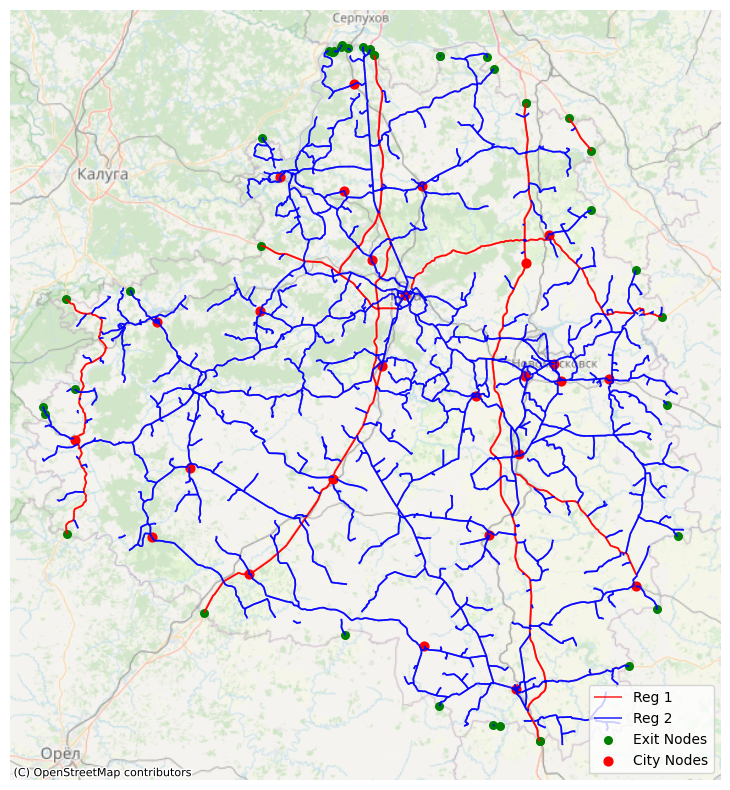

In [5]:
from transport_frames.frame import get_frame, plot_frame

f = get_frame(g.graph,region_points,polygon,regions)

plot_frame(f)

# weights

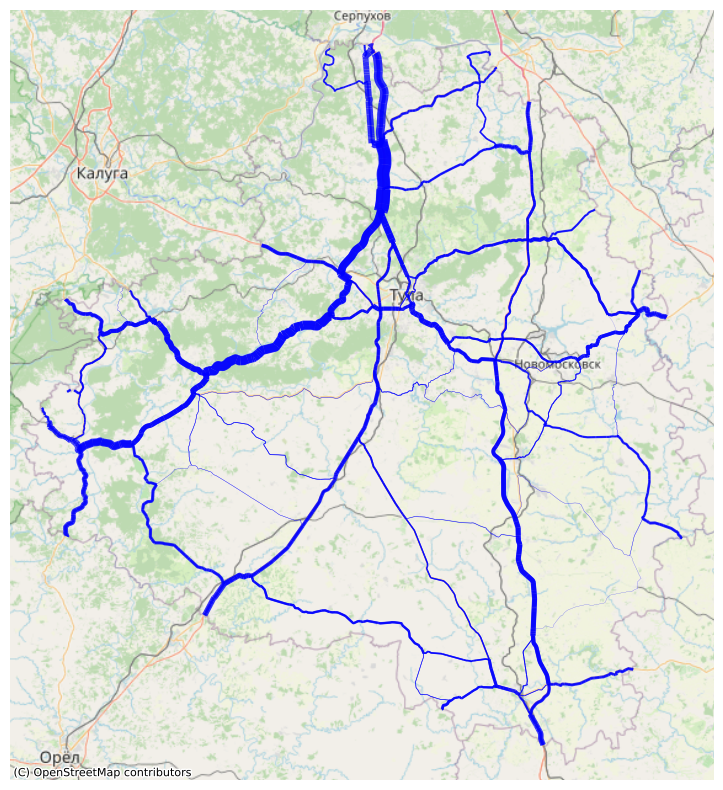

In [7]:
from transport_frames.frame import weigh_roads, plot_weighted_roads

weighted_frame = weigh_roads(f)

plot_weighted_roads(weighted_frame)